# 02 — LightGBM

Gradient-boosted trees on the same adstocked/saturated media features as notebook 01, plus `division` as a native categorical feature (trees don't need dummy columns) and `month`. Same shared time-based holdout.

**The `sales_lag1` leakage question.** The original notebook included last week's actual sales as a feature and reported R²=0.888. That's a real number, but it isn't a media-planning result: you can't act on "last week's sales" the way you can act on a spend decision, and it tells you nothing about which channel to fund next quarter. This notebook fits **both versions** and reports them side by side, exactly as the project brief asked for.

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from mmm import data as D
from mmm.eval import metrics

df = D.load_panel()
df["month"] = df["calendar_week"].dt.month
df["div_code"] = df["division"].astype("category")
df["sales_lag1"] = df.groupby("division")["sales"].shift(1)  # lag computed WITHIN each division

train_weeks, test_weeks = D.time_split_weeks(df)
tr_mask = df["calendar_week"].isin(train_weeks)
te_mask = df["calendar_week"].isin(test_weeks)
y = df[D.TARGET]

media_feat = D.build_transformed_features(df, theta=0.5, gamma_frac=0.25, train_weeks=train_weeks)
base_feat = pd.concat([media_feat, df[D.CONTROL_VARS], df[["month", "div_code"]]], axis=1)

lgb_params = dict(n_estimators=500, learning_rate=0.03, num_leaves=15, max_depth=4,
                   min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                   reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=-1)


## Spend-only model (the media-planning-relevant one)

C:\Users\Georges Ghosn\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Georges Ghosn\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Georges Ghosn\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Georges Ghosn\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, execu

LightGBM (spend-only) holdout: {'R2': 0.8098411439990697, 'RMSE': 73553.14498485893, 'MAPE': 0.2502779809997127}


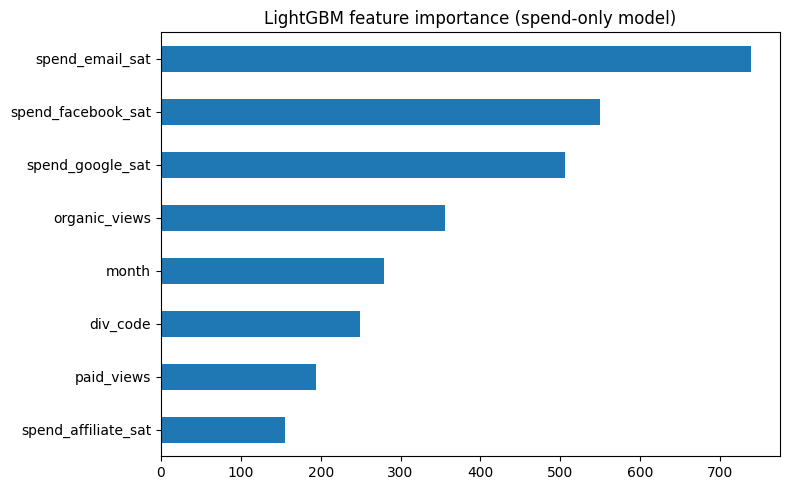

In [2]:
m_spend = lgb.LGBMRegressor(**lgb_params)
m_spend.fit(base_feat.loc[tr_mask], y.loc[tr_mask], categorical_feature=["div_code"])
pred_spend = m_spend.predict(base_feat.loc[te_mask])
metrics_spend = metrics(y.loc[te_mask], pred_spend)
print("LightGBM (spend-only) holdout:", metrics_spend)

importance = pd.Series(m_spend.feature_importances_, index=base_feat.columns).sort_values(ascending=False)
importance.plot(kind="barh", figsize=(8, 5), title="LightGBM feature importance (spend-only model)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/figures/02_lightgbm_importance_spend_only.png", dpi=110)
plt.show()


## With `sales_lag1` (nowcasting variant, for comparison only)

In [3]:
feat_lag = base_feat.copy()
feat_lag["sales_lag1"] = df["sales_lag1"]
valid = feat_lag["sales_lag1"].notna()  # first week of each division has no lag

m_lag = lgb.LGBMRegressor(**lgb_params)
m_lag.fit(feat_lag.loc[tr_mask & valid], y.loc[tr_mask & valid], categorical_feature=["div_code"])
pred_lag = m_lag.predict(feat_lag.loc[te_mask & valid])
metrics_lag = metrics(y.loc[te_mask & valid], pred_lag)
print("LightGBM (with sales_lag1) holdout:", metrics_lag)

importance_lag = pd.Series(m_lag.feature_importances_, index=feat_lag.columns).sort_values(ascending=False)
print()
print(importance_lag)


LightGBM (with sales_lag1) holdout: {'R2': 0.8570976434151514, 'RMSE': 63762.107680279674, 'MAPE': 0.2095647723949237}

spend_email_sat        571
sales_lag1             544
spend_facebook_sat     430
spend_google_sat       426
organic_views          354
month                  236
spend_affiliate_sat    172
paid_views             161
div_code               161
dtype: int32


`sales_lag1` dominates feature importance and lifts R² further — exactly the leakage pattern the brief flagged. It's a legitimate feature for a short-term sales *nowcast*, but it answers a different question than "how should we allocate next quarter's media budget," because it isn't something a planner controls. **The spend-only model above is the one used for the channel/ROI conclusions in notebook 05**; the lag variant is reported here only for comparison, not used for budget decisions.

In [4]:
comparison = pd.DataFrame({"spend_only": metrics_spend, "with_sales_lag1": metrics_lag}).T
comparison.to_csv("../reports/lightgbm_metrics.csv")
importance.to_csv("../reports/lightgbm_importance_spend_only.csv")
comparison


,R2,RMSE,MAPE
spend_only,0.809841,73553.144985,0.250278
with_sales_lag1,0.857098,63762.107680,0.209565
